#import required libraries for the all required to perform data preprocessing, exploratory data analysis, feature engineering, model training, and performance evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
import pandas as pd
#loading the data set from local drive
df = pd.read_csv("insurance.csv")


In [5]:
#2. Plan for the Analysis

## 1. Exploratory Data Analysis (EDA)

# I will begin with exploring the dataset to contextualise the information on it.
# I will assess the number of rows and columns, the varying data types, and search for any lacking values or repeating records.
# I will also search at the distribution of variables such as age, BMI and medical charges.
# I will use graphs to find any anomalies and to see how the varying variables are correlated to medical charges.

## 2. Feature Selection

# I will prepare the variables that will be used to predict medical charges.
# Since variables such as sex, smoker and region have words instead of numerical values, I will convert them into numerical values.
# I will then check which variables have a meaningful relationship with medical charges.
# I will use p-values to help decide which variables should stay in the model.
# I will also check for multicollinearity using VIF to make sure the predictor variables are not too strongly related to each other.

## 3. Model Training

# I will divide the dataset into training data and testing data.
# I will use 80% of the data to train the model and 20% to test the model.
# I will train a Multiple Linear Regression model because there are many variables that may impact medical charges.
# The model will learn from the training data and will then be utilised to forecast medical charges for the test data.

## 4. Model Evaluation

# I will compare the forecasted medical charges with the actual medical charges.
# I will use R-squared to see how much of the variation in medical charges is explained by the model.
# I will also use MAE and RMSE to quantify how far the predictions are from the actual charges.
# I will analyse the residuals to check whether the Linear Regression model is relevant for the data.

## 5. Retraining the Model

# If the first model does not perform well, I will try to improve it.
# This may involve removing variables that are not unneeded, changing some variables, or adding interaction terms.
# I will then compare the novel model with the original model to see whether its performance has gotten better.

## 6. Report

# Finally, I will create a report explaining the results of the analysis.
# The report will include the data cleaning process, EDA findings, feature selection and model training.
# I will also explain the model results, its performance, any limitations, and my final recommendations.

In [6]:
#Examine the Dataset
#Analyse the dataset to see if it is suitable for applying a Linear Regression algorithm.

In [7]:
#print the top 5 records
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
#print and show every column name and the data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 57.6 KB


In [9]:
#print out dimensions of the dataset
print("Dataset shape:", df.shape)

Dataset shape: (1338, 7)


In [10]:
#print missing values or NaN validation
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [11]:
#print  duplicate observations Check
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 1


In [12]:
#there is one duplicate and which will be removed as it should not distort the data set 
df = df.drop_duplicates().copy() #we rename the existing df with a new dataframe after removing duplicates 

# we recheck the duplicate again 
print("\nDuplicate rows:", df.duplicated().sum())

#we print out the dimension of the dataset 
print("Dataset shape:", df.shape)


Duplicate rows: 0
Dataset shape: (1337, 7)


In [13]:
#2. Plan for the Analysis

## 1. Exploratory Data Analysis (EDA)

# I will begin with exploring the dataset to contextualise the information on it.
# I will assess the number of rows and columns, the varying data types, and search for any lacking values or repeating records.
# I will also search at the distribution of variables such as age, BMI and medical charges.
# I will use graphs to find any anomalies and to see how the varying variables are correlated to medical charges.

## 2. Feature Selection

# I will prepare the variables that will be used to predict medical charges.
# Since variables such as sex, smoker and region have words instead of numerical values, I will convert them into numerical values.
# I will then check which variables have a meaningful relationship with medical charges.
# I will use p-values to help decide which variables should stay in the model.
# I will also check for multicollinearity using VIF to make sure the predictor variables are not too strongly related to each other.

## 3. Model Training

# I will divide the dataset into training data and testing data.
# I will use 80% of the data to train the model and 20% to test the model.
# I will train a Multiple Linear Regression model because there are many variables that may impact medical charges.
# The model will learn from the training data and will then be utilised to forecast medical charges for the test data.

## 4. Model Evaluation

# I will compare the forecasted medical charges with the actual medical charges.
# I will use R-squared to see how much of the variation in medical charges is explained by the model.
# I will also use MAE and RMSE to quantify how far the predictions are from the actual charges.
# I will analyse the residuals to check whether the Linear Regression model is relevant for the data.

## 5. Retraining the Model

# If the first model does not perform well, I will try to improve it.
# This may involve removing variables that are not unneeded, changing some variables, or adding interaction terms.
# I will then compare the novel model with the original model to see whether its performance has gotten better.

## 6. Report

# Finally, I will create a report explaining the results of the analysis.
# The report will include the data cleaning process, EDA findings, feature selection and model training.
# I will also explain the model results, its performance, any limitations, and my final recommendations.

In [14]:
#Descriptive statistics
#Generatimg descriptive statistics for all the numerical variables 
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [15]:
#Generatimg descriptive statistics for all the categorical variables, we check the frequency and distributions

for column in ["sex", "smoker", "region"]:
    print(f"\n{column.upper()}")
    print(df[column].value_counts())


SEX
sex
male      675
female    662
Name: count, dtype: int64

SMOKER
smoker
no     1063
yes     274
Name: count, dtype: int64

REGION
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


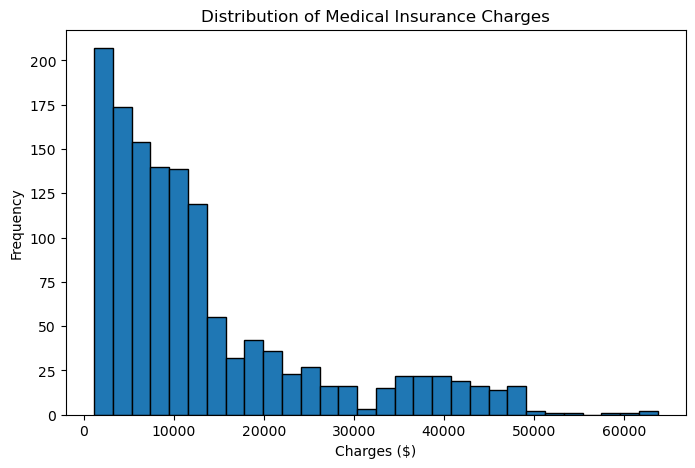

In [16]:
#we need to do distribution of Charges and it is the dependent variable
import matplotlib.pyplot as plt

#we make the distribution of the target variable
plt.figure(figsize=(8, 5))
plt.hist(df["charges"], bins=30, edgecolor="black")

#we add labels and titles on the graph
plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Charges ($)")
plt.ylabel("Frequency")

#we show the graph
plt.show()

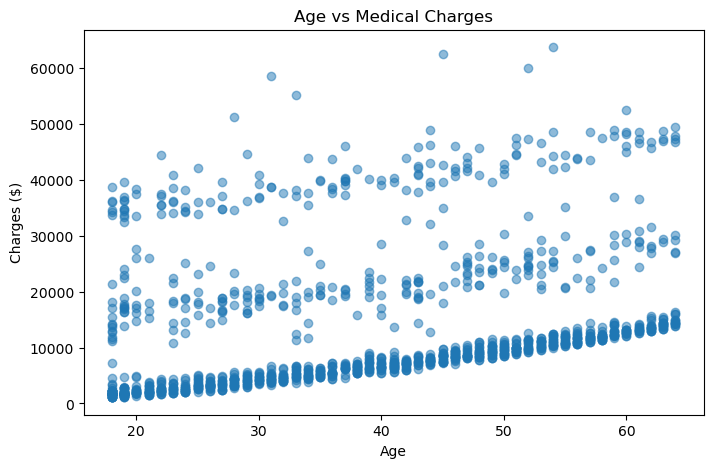

In [17]:
#age vs Charges

plt.figure(figsize=(8, 5))

plt.scatter(df["age"], df["charges"], alpha=0.5)

plt.title("Age vs Medical Charges")
plt.xlabel("Age")
plt.ylabel("Charges ($)")
plt.show()


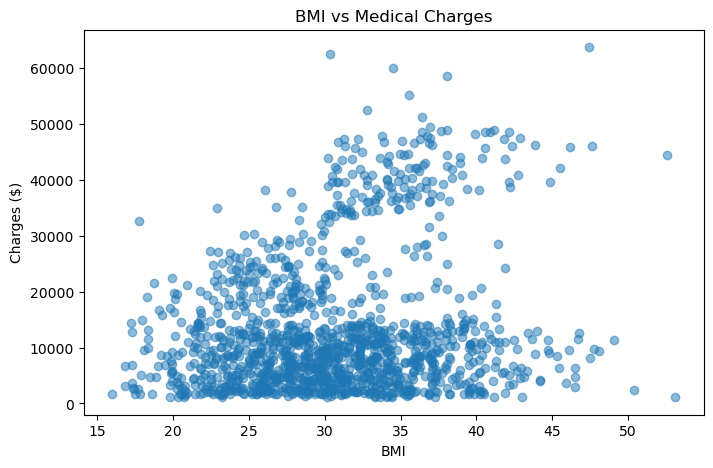

In [18]:
#BMI vs Charges
plt.figure(figsize=(8, 5))

plt.scatter(df["bmi"], df["charges"], alpha=0.5)

plt.title("BMI vs Medical Charges")
plt.xlabel("BMI")
plt.ylabel("Charges ($)")
plt.show()


<Figure size 700x500 with 0 Axes>

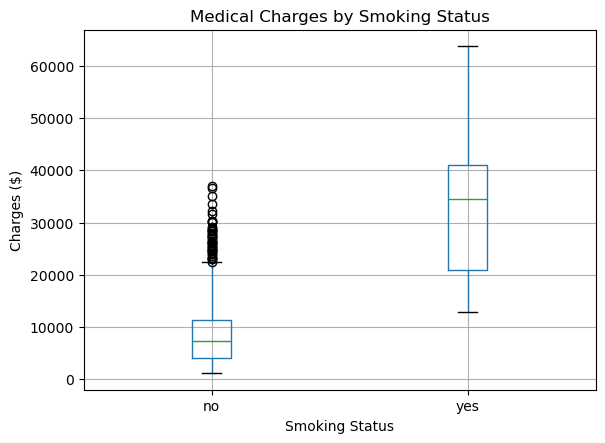

In [19]:
# Smoking

# Compare the medical charges of smokers and non-smokers
# Calculate the number of people, average, median and standard deviation of charges
smoker_summary = df.groupby("smoker")["charges"].agg(
    ["count", "mean", "median", "std"]
)

# Display the results
smoker_summary

# Create a boxplot to compare the medical charges of smokers and non-smokers
plt.figure(figsize=(7, 5))

df.boxplot(column="charges", by="smoker")

# Add a title and labels to make the graph easier to understand
plt.title("Medical Charges by Smoking Status")
plt.suptitle("")
plt.xlabel("Smoking Status")
plt.ylabel("Charges ($)")

# Display the graph
plt.show()

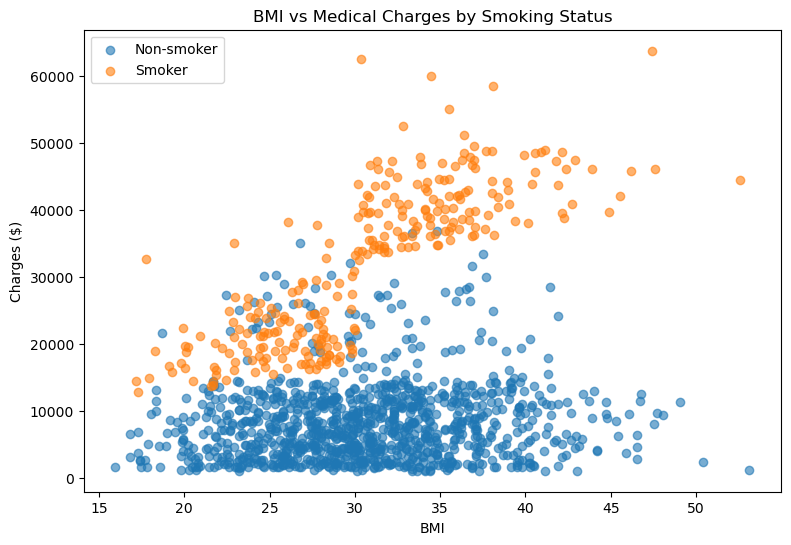

In [20]:
#BMI vs Charges by Smoking Status

# Separate the dataset into smokers and non-smokers
smokers = df[df["smoker"] == "yes"]
non_smokers = df[df["smoker"] == "no"]

# Create the scatter plot
plt.figure(figsize=(9, 6))

# Plot non-smokers
plt.scatter(
    non_smokers["bmi"],
    non_smokers["charges"],
    alpha=0.6,
    label="Non-smoker"
)

# Plot smokers
plt.scatter(
    smokers["bmi"],
    smokers["charges"],
    alpha=0.6,
    label="Smoker"
)

plt.title("BMI vs Medical Charges by Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Charges ($)")
plt.legend()
plt.show()


In [21]:
#Sex
# Compare average charges by sex
df.groupby("sex")["charges"].agg(["count", "mean", "median"])


,count,mean,median
sex,,,
female,662,12569.578844,9412.9625
male,675,13974.998864,9377.9047


In [22]:
#Region
# Compare medical charges across geographic regions
df.groupby("region")["charges"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

,count,mean,median
region,,,
southeast,364,14735.411438,9294.131950
northeast,324,13406.384516,10057.652025
northwest,324,12450.840844,8976.977250
southwest,325,12346.937377,8798.593000


In [23]:
#Children
#examining average charges according to number of children
df.groupby("children")["charges"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
children,,,
0,573,12384.695344,9863.47180
1,324,12731.171832,8483.87015
2,240,15073.563734,9264.97915
3,157,15355.318367,10600.54830
4,25,13850.656311,11033.66170
5,18,8786.035247,8589.56505


In [24]:
#Correlation
# Correlation

# Check how age, BMI and number of children are related to medical charges
correlation_matrix = df[
    ["age", "bmi", "children", "charges"]
].corr()

# Display the results
correlation_matrix


,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


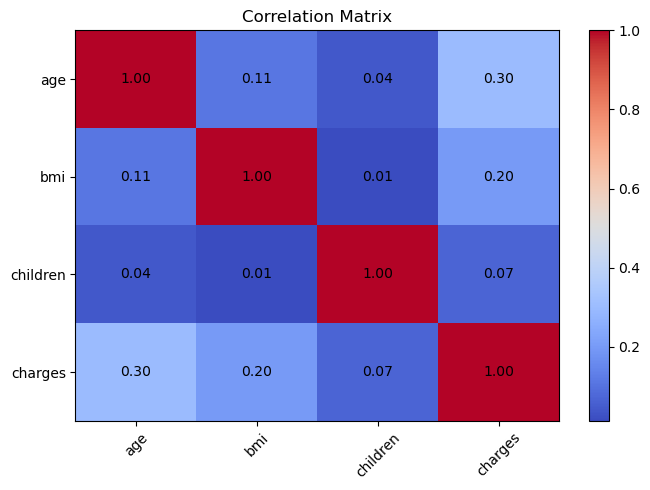

In [25]:
#visualisation of the correlation coefficient 

plt.figure(figsize=(7, 5))

plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar()

#adding the correlation values inside each square
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j, i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

#adding the cariable namesto the x-axis
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

#adding the cariable names
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

# Add a title to the chart
plt.title("Correlation Matrix")

plt.tight_layout()

# Display the chart
plt.show()

In [26]:
#Feature Selection
# we convert the categorical variables into numbers so they can be used in the regression model
# we drop_first=True removes one category from each variable to avoid duplicate information

df_encoded = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"],
    drop_first=True,
    dtype=int
)

# Display the first five rows to check that the variables were converted correctly
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [27]:
#we define the dependent variable (target or Y)
y = df_encoded["charges"]

#we define the independent variables (predictors or X)
X = df_encoded.drop(columns=["charges"])

print("Predictor variables:")
print(X.columns.tolist())

Predictor variables:
['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


In [28]:
# Import statsmodels to help us check which variables are important in the model
import statsmodels.api as sm

# Add a constant so that the regression model includes an intercept
X_const = sm.add_constant(X)

# Create and train the Multiple Linear Regression model
full_model = sm.OLS(y, X_const).fit()

# Display the results of the regression model
print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.0
Date:                Tue, 15 Sep 2026   Prob (F-statistic):               0.00
Time:                        00:44:35   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    988.227  

In [29]:
# Display the p-values for each predictor variable
# A significance level of 0.05 is used.
# Variables with p-values <= 0.05 are considered statistically significant.

p_values = full_model.pvalues.drop("const")

p_values.sort_values()

smoker_yes          0.000000e+00
age                 1.324461e-88
bmi                 6.721670e-31
children            5.925434e-04
region_southeast    3.080353e-02
region_southwest    4.483556e-02
region_northwest    4.640527e-01
sex_male            6.976303e-01
dtype: float64

In [30]:
# Create a table of p-values from the OLS regression model
p_value_table = full_model.pvalues.drop("const").reset_index()

# Rename the columns
p_value_table.columns = ["Feature", "p-value"]

# Classify each feature using a 5% significance level
p_value_table["Result"] = p_value_table["p-value"].apply(
    lambda p: "Significant" if p <= 0.05 else "Not significant"
)

# Format the p-values for easier interpretation
p_value_table["p-value"] = p_value_table["p-value"].apply(
    lambda p: "< 0.001" if p < 0.001 else f"{p:.3f}"
)

# Display the table
p_value_table

,Feature,p-value,Result
0,age,< 0.001,Significant
1,bmi,< 0.001,Significant
2,children,< 0.001,Significant
3,sex_male,0.698,Not significant
4,smoker_yes,< 0.001,Significant
5,region_northwest,0.464,Not significant
6,region_southeast,0.031,Significant
7,region_southwest,0.045,Significant


In [31]:
# Select predictor variables that are statistically significant
# at the 5% significance level.

selected_features = p_values[
    p_values <= 0.05
].index.tolist()

print("Selected features:")
print(selected_features)


### Feature Selection

# P-values from the full OLS regression model were used to select the most relevant predictor variables.
# A **5% significance level (0.05)** was used.
# Variables with **p-values ≤ 0.05** were considered statistically significant and selected for model training.
# The statistically significant variables were:

  # `age`
  # `bmi`
  # `children`
  # `smoker_yes`
  # `region_southeast`
  # `region_southwest`
# `sex_male` (**p = 0.698**) and `region_northwest` (**p = 0.464**) were not statistically significant and were therefore excluded using this feature-selection criterion.
# The selected variables will be used to train the Linear Regression model.

Selected features:
['age', 'bmi', 'children', 'smoker_yes', 'region_southeast', 'region_southwest']


In [32]:
# Select predictor variables that are statistically significant
# at the 5% significance level.

selected_features = p_values[
    p_values <= 0.05
].index.tolist()

print("Selected features:")
print(selected_features)

Selected features:
['age', 'bmi', 'children', 'smoker_yes', 'region_southeast', 'region_southwest']


In [33]:
# Select variables with p-values less than or equal to 0.05
selected_features = full_model.pvalues.drop("const")[
    full_model.pvalues.drop("const") <= 0.05
].index.tolist()

# Create the final predictor dataset using the selected variables
X_selected = X[selected_features]

print("Selected features:")
print(selected_features)

Selected features:
['age', 'bmi', 'children', 'smoker_yes', 'region_southeast', 'region_southwest']


In [34]:
# 3c. Train the Linear Regression Model

# Split the data into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42
)

# Create the Linear Regression model using the default parameters
linear_model = LinearRegression()

# Train the model using the training data
linear_model.fit(X_train, y_train)

# Use the trained model to predict charges for the test data
y_pred = linear_model.predict(X_test)

# Display the number of observations used for training and testing
print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

<class 'NameError'>: name 'train_test_split' is not defined

In [ ]:
# 4a. Interpret and Evaluate the Model

# Calculate R-squared
# R-squared measures the proportion of variation in medical charges
# that is explained by the model.
r2 = r2_score(y_test, y_pred)

# Calculate Mean Absolute Error (MAE)
# MAE shows the average absolute difference between the
# actual medical charges and the model's predicted charges.
mae = mean_absolute_error(y_test, y_pred)

# Calculate Root Mean Squared Error (RMSE)
# RMSE measures prediction error but gives more weight to
# large prediction errors.
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate Adjusted R-squared
# Adjusted R-squared accounts for the number of predictor
# variables included in the model.
n = len(y_test)
p = X_test.shape[1]

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - p - 1)
)

# Display the model performance results
print(f"R-squared: {r2:.4f}")
print(f"Adjusted R-squared: {adjusted_r2:.4f}")
print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")

In [ ]:
# Create a table to summarise the model evaluation metrics
evaluation_results = pd.DataFrame({
    "Metric": [
        "R-squared",
        "Adjusted R-squared",
        "MAE",
        "RMSE"
    ],
    "Value": [
        round(r2, 4),
        round(adjusted_r2, 4),
        round(mae, 2),
        round(rmse, 2)
    ]
})

evaluation_results

# R-squared was selected because it shows how much of the variation
# in medical charges is explained by the predictor variables.

# Adjusted R-squared was included because the model contains several
# predictor variables and it adjusts for the number of variables used.

# MAE was selected because it shows the average prediction error
# in the same monetary units as medical charges.

# RMSE was included because it gives greater weight to large
# prediction errors and therefore helps identify whether the model
# makes some particularly large errors.

In [ ]:
# Compare the actual medical charges with the predicted charges

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Add a reference line representing perfect predictions
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.title("Actual vs Predicted Medical Charges")
plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")
plt.show()

In [ ]:
# Calculate the residuals
# A residual is the difference between the actual and predicted charge.
residuals = y_test - y_pred

# Plot residuals against predicted charges
plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

# Add a horizontal line at zero
plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residuals vs Predicted Charges")
plt.xlabel("Predicted Charges ($)")
plt.ylabel("Residuals ($)")
plt.show()


# the aim is for the residuals should be randomly scattered around zero.
# A clear pattern or funnel shape may indicate that the assumptions
# of Linear Regression are not fully satisfied.

In [ ]:
# Examine the distribution of the residuals

plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Regression Residuals")
plt.xlabel("Residual ($)")
plt.ylabel("Frequency")
plt.show()